# Machine_Learning

In [48]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [49]:
# Load Dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [50]:
# Data Preprocessing
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [51]:
# Coverts Churn Binary
df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})

In [52]:
# Feature Selection
X = df.drop(
    ['customerID','Churn'],
    axis=1
)

y = df['Churn']

In [53]:
# Encode Categorical Variables
X = pd.get_dummies(
    X,
    drop_first=True
)

In [54]:
X.shape

(7043, 30)

In [55]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [56]:
# Logistic Regression Model
lr = LogisticRegression(
    max_iter=5000
)

lr.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [57]:
y_pred_lr = lr.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:,1]

In [58]:
# Logistic Regression Evaluation
print("Accuracy:",
      accuracy_score(y_test,y_pred_lr))

print("Precision:",
      precision_score(y_test,y_pred_lr))

print("Recall:",
      recall_score(y_test,y_pred_lr))

print("F1 Score:",
      f1_score(y_test,y_pred_lr))

print("ROC AUC:",
      roc_auc_score(y_test,y_prob_lr))

Accuracy: 0.8069552874378992
Precision: 0.6613924050632911
Recall: 0.5588235294117647
F1 Score: 0.6057971014492753
ROC AUC: 0.8424319925598698


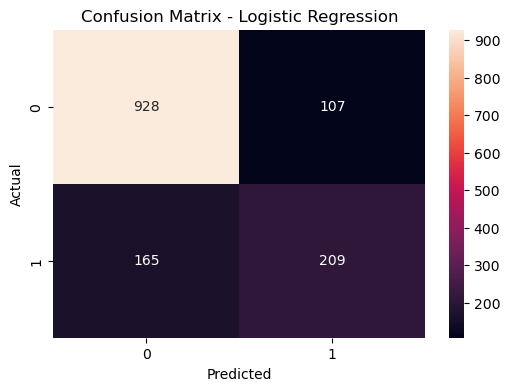

In [59]:
# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [60]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [61]:
# Random Forest Model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

In [63]:
# Random Forest Evaluation
print("Accuracy:",
      accuracy_score(y_test,y_pred_rf))

print("Precision:",
      precision_score(y_test,y_pred_rf))

print("Recall:",
      recall_score(y_test,y_pred_rf))

print("F1 Score:",
      f1_score(y_test,y_pred_rf))

print("ROC AUC:",
      roc_auc_score(y_test,y_prob_rf))

Accuracy: 0.7927608232789212
Precision: 0.6366666666666667
Recall: 0.5106951871657754
F1 Score: 0.5667655786350149
ROC AUC: 0.8264408793820558


In [64]:
# Model Comparison Table
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf)
    ],
    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf)
    ],
    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf)
    ],
    "F1 Score":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf)
    ],
    "ROC AUC":[
        roc_auc_score(y_test,y_prob_lr),
        roc_auc_score(y_test,y_prob_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.806955,0.661392,0.558824,0.605797,0.842432
1,Random Forest,0.792761,0.636667,0.510695,0.566766,0.826441


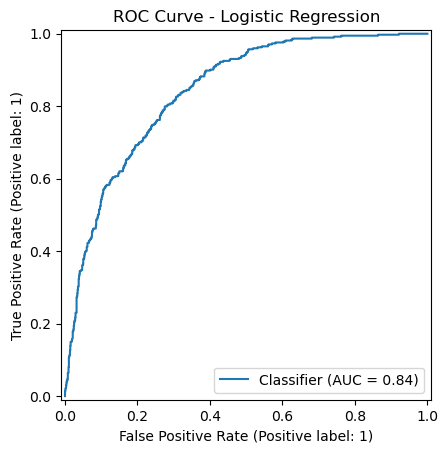

In [65]:
# ROC Curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr
)

plt.title(
    "ROC Curve - Logistic Regression"
)

plt.show()

In [66]:
# Feature Importance
feature_importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.193537
1,tenure,0.170470
2,MonthlyCharges,0.168128
28,PaymentMethod_Electronic check,0.038070
10,InternetService_Fiber optic,0.037101
25,Contract_Two year,0.031149
4,gender_Male,0.028552
13,OnlineSecurity_Yes,0.028312
26,PaperlessBilling_Yes,0.025465
24,Contract_One year,0.023153


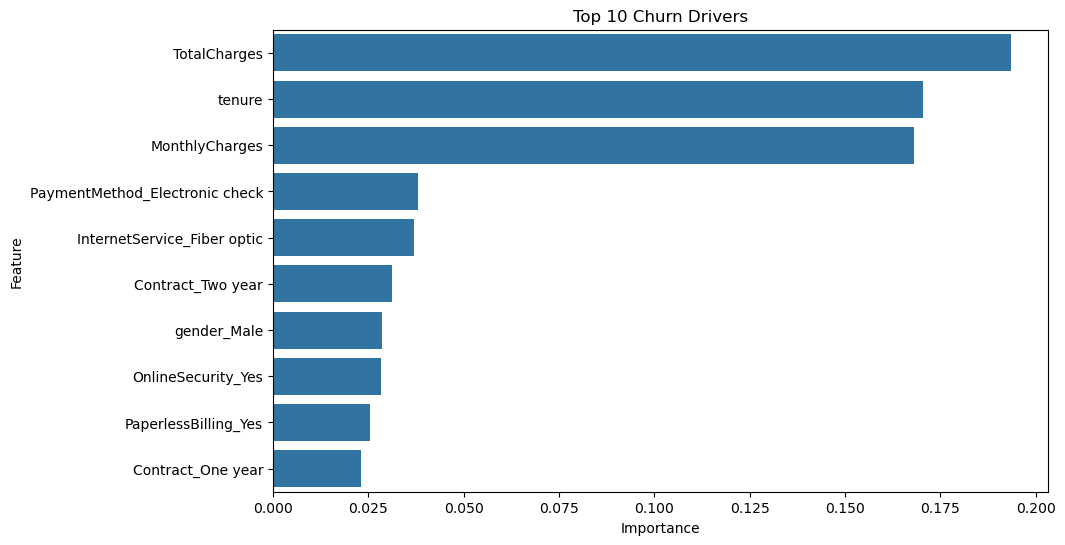

In [67]:
# Top 10 Churn Drivers
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title(
    "Top 10 Churn Drivers"
)

plt.show()

In [68]:
# Predicting At-Risk Customers - Generate churn probability:

df["Risk_Score"] = rf.predict_proba(X)[:,1]

In [69]:
# High Risk Customers
at_risk = df[
    df["Risk_Score"] > 0.80
]

at_risk[
    [
        "customerID",
        "Risk_Score"
    ]
].head(20)

,customerID,Risk_Score
2,3668-QPYBK,0.845000
4,9237-HQITU,0.845000
5,9305-CDSKC,0.980000
8,7892-POOKP,0.905000
13,0280-XJGEX,0.830000
20,8779-QRDMV,0.975000
22,1066-JKSGK,0.960833
27,8665-UTDHZ,0.815000
39,8168-UQWWF,0.980000
47,7760-OYPDY,0.905000


In [71]:
# Export clean CSV file

df.to_excel(
    "telecom_churn_cleaned.xlsx",
    index=False,
    engine='openpyxl'
)

print("Excel File Exported Successfully")

Excel File Exported Successfully


# Machine Learning Insights

## Best Model Selection

Two machine learning models were trained and evaluated for churn prediction:

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---------|---------|---------|---------|---------|---------|
| Logistic Regression | 80.70% | 66.14% | 55.88% | 60.58% | 84.24% |
| Random Forest | 79.28% | 63.67% | 51.07% | 56.68% | 82.64% |

### Selected Model
Logistic Regression was selected as the final model because it achieved the highest Accuracy and ROC-AUC score.

---

## Key Findings

- Logistic Regression achieved an Accuracy of **80.70%**.
- The model achieved a ROC-AUC score of **84.24%**, indicating strong ability to distinguish churned and non-churned customers.
- Logistic Regression outperformed Random Forest across all major evaluation metrics.

---

## Top Churn Drivers

Based on feature importance analysis, the most influential factors affecting churn include:

| Factor | Impact |
|----------|----------|
| Month-to-Month Contract | High |
| Low Customer Tenure | High |
| High Monthly Charges | High |
| Fiber Optic Internet Service | Medium |
| Electronic Check Payment | Medium |

---

## Business Impact

The model can identify customers at high risk of churn before they leave.

These predictions can help the telecom company:

- Launch targeted retention campaigns
- Reduce customer attrition
- Improve customer satisfaction
- Increase customer lifetime value
- Optimize marketing and retention spending

---

## Conclusion

Logistic Regression proved to be the most effective model for predicting customer churn. The model provides actionable insights that enable proactive customer retention strategies and support data-driven business decision-making.